# In-Competition Bayesian Calibration Evaluation

Tests whether **Bayesian Poisson calibration** (updating after each real result) improves
prediction quality during three major competitions:

| Fold | Competition | Matches | Dates |
|------|-------------|---------|-------|
| A | **World Cup 2018** | 64 | Jun 14 – Jul 15, 2018 |
| B | **World Cup 2022** | 64 | Nov 20 – Dec 18, 2022 |
| C | **Euro 2024** | 51 | Jun 14 – Jul 14, 2024 |

Across two score-conversion **strategies** (V4, V6), each using the same
**0.9 LGBM + 0.1 XGB ensemble** architecture as the production models — but
retrained from scratch on a temporal holdout to prevent data leakage.

| Strategy | Model | Features | Mirror | Score rule |
|----------|-------|----------|--------|------------|
| V4 | Ensemble (LGBM+XGB, V4 mirror) | 20 V4 feats | `mirror_features` | `floor(λ+0.1)` |
| V6 | Ensemble (V6LGBM+V6XGB, corrected mirror) | 20 V5 feats | `mirror_features_v6` | Dixon-Coles drawband |

**Key design choices**
- Each model is retrained from scratch on data *strictly before* the competition starts (no leakage).
- Games within each competition are simulated in chronological order.
- After each game the calibration state is updated with the actual score — the next prediction uses the updated goal-scale and draw-adjustment factors.
- Metrics are computed both with and without calibration to isolate its effect.

**Calibration mechanics** (Bayesian Poisson, two parallel updates):
1. *Goal-rate*: prior = model is unbiased (ratio = 1.0), weight = 48 effective games.
   `goal_scale = (48 × 1.0 + n × obs_ratio) / (48 + n)`
2. *Draw-rate*: Beta(α, β) prior fitted from major tournament history (excluding the test competition).
   `posterior_draw_rate = (α + draws) / (α + β + n)`

**Metrics**
- **Exact %** — fraction of games where predicted score = actual score (integer match)
- **Result %** — fraction of games where W/D/L prediction is correct
- **RPS** — Ranked Probability Score on W/D/L probabilities (lower = better)

In [1]:
import sys
from pathlib import Path

# Make src importable when running from notebooks/
ROOT = Path('.').resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import warnings
from copy import deepcopy
from functools import partial

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Python path root:', ROOT)

Python path root: C:\Users\yuval\WC_Predictor


c:\Users\yuval\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\yuval\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
import subprocess, sys, importlib

# pandas requires jinja2 >= 3.1.5; upgrade in-place in this kernel's environment
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '--upgrade', 'jinja2>=3.1.5', '-q'],
    check=True,
)
importlib.invalidate_caches()

# If jinja2 was already imported at the old version, reload it
import jinja2
if tuple(int(x) for x in jinja2.__version__.split('.')[:3]) < (3, 1, 5):
    importlib.reload(jinja2)

import jinja2
from pandas.io.formats.style import Styler as _PandasStyler
print(f'jinja2 {jinja2.__version__} — Styler ready')

jinja2 3.1.6 — Styler ready


In [3]:
# ── Source imports ──────────────────────────────────────────────────────────
from src.models.lgbm_model import LGBMGoalModel
from src.models.xgb_model import XGBGoalModel
from src.models.ensemble import EnsembleGoalModel
from src.models.goal_models_v6 import V6LGBMGoalModel, V6XGBGoalModel, build_v6_ensemble
from src.models.score_conversion import (
    most_likely_score, most_likely_score_v5, most_likely_score_v6,
    win_draw_loss_probs,
)
from src.models.weighting import apply_competition_weights, COMPETITION_WEIGHTS
from src.features.feature_columns import FEATURE_COLS, FEATURE_COLS_V5_PROD
from src.state.tournament_calibration import (
    initialize_calibration, add_game, get_factors,
    calibrate_lambdas, calibrate_win_draw_loss,
    _make_prior, PRIOR_N_EFFECTIVE,
)
from src.evaluation.metrics import rps_result

print('Imports OK')
print(f'V4 features: {len(FEATURE_COLS)}')
print(f'V5/V6 features: {len(FEATURE_COLS_V5_PROD)}')

Imports OK
V4 features: 20
V5/V6 features: 20


## 1 — Load dataset and add V5/V6 features

In [4]:
df = pd.read_csv(ROOT / 'data/processed/updated_model_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Standardise target column names
df = df.rename(columns={'target_goals_a': 'goals_A', 'target_goals_b': 'goals_B'})

# ── Add V5 / V6 features that aren't pre-computed in the dataset ────────────
# rest_diff: signed rest advantage (negated by V6 mirror, not by V4/V5 mirror)
df['rest_diff'] = df['team_a_days_since_last_match'] - df['team_b_days_since_last_match']

# competition_importance: numeric K-weight from the competition weights dict
def _comp_importance(comp: str) -> float:
    comp_lower = comp.lower()
    for key, weight in COMPETITION_WEIGHTS.items():
        if key.lower() in comp_lower:
            return float(weight)
    return 1.0

df['competition_importance'] = df['competition'].apply(_comp_importance)

print(f'Dataset: {len(df):,} rows, {df.columns.tolist()}')
print(f'Date range: {df["date"].min().date()} – {df["date"].max().date()}')

# Verify all required features are present
missing_v4 = [c for c in FEATURE_COLS        if c not in df.columns]
missing_v5 = [c for c in FEATURE_COLS_V5_PROD if c not in df.columns]
print(f'Missing V4 features: {missing_v4}')
print(f'Missing V5/V6 features: {missing_v5}')

Dataset: 21,655 rows, ['date', 'team_a', 'team_b', 'competition', 'location', 'season_id', 'tournament_year', 'tournament_key', 'rank_diff', 'elo_diff', 'rating_a_before', 'rating_b_before', 'avg_player_value_diff', 'log_market_value_a', 'market_value_rel_mean_diff', 'opponent_strength_diff_last5', 'weighted_goals_for_diff_last5', 'weighted_goals_against_diff_last5', 'rating_change_diff_last5', 'team_a_matches_played_before', 'team_b_matches_played_before', 'team_a_days_since_last_match', 'team_b_days_since_last_match', 'team_a_tournament_matches_played', 'team_b_tournament_matches_played', 'tournament_points_diff', 'tournament_goal_diff_diff', 'goalkeeper_share_diff', 'defender_share_diff', 'goals_A', 'goals_B', 'target_goal_diff', 'target_total_goals', 'rest_diff', 'competition_importance']
Date range: 2004-01-01 – 2026-06-08
Missing V4 features: []
Missing V5/V6 features: []


## 2 — Fold & Strategy Configuration

In [5]:
# ── Fold definitions ────────────────────────────────────────────────────────
# test_mask: selects the test competition rows in df
# cutoff: strictly before this date → training rows

FOLDS = {
    'WC 2018': {
        'test_mask': (
            df['competition'].str.lower().str.contains('world cup', na=False) &
            ~df['competition'].str.lower().str.contains('qualifier', na=False) &
            (df['tournament_year'] == 2018)
        ),
        'cutoff': pd.Timestamp('2018-06-14'),
    },
    'WC 2022': {
        'test_mask': (
            df['competition'].str.lower().str.contains('world cup', na=False) &
            ~df['competition'].str.lower().str.contains('qualifier', na=False) &
            (df['tournament_year'] == 2022)
        ),
        'cutoff': pd.Timestamp('2022-11-20'),
    },
    'Euro 2024': {
        'test_mask': (
            (df['competition'] == 'European Championship') &
            (df['tournament_year'] == 2024)
        ),
        'cutoff': pd.Timestamp('2024-06-14'),
    },
}

for fold_name, cfg in FOLDS.items():
    test_df = df[cfg['test_mask']].sort_values('date')
    train_df = df[df['date'] < cfg['cutoff']]
    print(f"{fold_name}: train={len(train_df):,}  test={len(test_df)} "
          f"({test_df['date'].min().date()} – {test_df['date'].max().date()})")
    cfg['test_df']  = test_df
    cfg['train_df'] = train_df

WC 2018: train=13,713  test=64 (2018-06-14 – 2018-07-15)
WC 2022: train=17,844  test=64 (2022-11-20 – 2022-12-18)
Euro 2024: train=19,549  test=51 (2024-06-14 – 2024-07-14)


In [6]:
# ── V6 drawband parameters (from production_config_v6.json) ─────────────────
import json
with open(ROOT / 'models/production_config_v6.json') as _f:
    _v6_cfg = json.load(_f)
_db = _v6_cfg.get('drawband', {})
V6_PARAMS = {
    'draw_threshold': _db.get('draw_threshold', 0.33),
    'threshold_b':   _db.get('threshold_b',   0.50),
    'scale_c':       _db.get('scale_c',        0.9992),
    'rho':           _db.get('rho',           -0.3294),
}
print('V6 drawband params:', V6_PARAMS)

# ── Strategy definitions ────────────────────────────────────────────────────
STRATEGIES = {
    'V4': {
        'feature_cols':  FEATURE_COLS,
        'model_factory': lambda: EnsembleGoalModel(
            [LGBMGoalModel(), XGBGoalModel()], weights=[0.9, 0.1]
        ),
        'score_fn':      most_likely_score,
        'description':   'Ensemble (0.9 LGBM + 0.1 XGB, V4 mirror) · 20 feats · floor(λ+0.1)',
    },
    'V6': {
        'feature_cols':  FEATURE_COLS_V5_PROD,
        'model_factory': build_v6_ensemble,
        'score_fn':      partial(most_likely_score_v6, **V6_PARAMS),
        'description':   'Ensemble (0.9 V6LGBM + 0.1 V6XGB, corrected mirror) · 20 V5 feats · drawband',
    },
}

# Populated later when blend strategies are defined (after models are trained)
_EXTRA_STRATEGIES: dict = {}

for s, cfg in STRATEGIES.items():
    print(f"{s}: {cfg['description']}")

V6 drawband params: {'draw_threshold': 0.33, 'threshold_b': 0.5, 'scale_c': 0.9992361938714952, 'rho': -0.3293651939032305}
V4: Ensemble (0.9 LGBM + 0.1 XGB, V4 mirror) · 20 feats · floor(λ+0.1)
V6: Ensemble (0.9 V6LGBM + 0.1 V6XGB, corrected mirror) · 20 V5 feats · drawband


## 3 — Helper Functions

In [7]:
def _make_prior_n(goals_per_game: float, draw_rate: float, n_source_games: int, prior_n: int) -> dict:
    """Like _make_prior() but with a configurable prior weight."""
    return {
        "goals_per_game": goals_per_game,
        "draw_rate":      draw_rate,
        "goal_prior_n":   prior_n,
        "draw_alpha":     draw_rate * prior_n,
        "draw_beta":      (1.0 - draw_rate) * prior_n,
        "n_source_games": n_source_games,
    }


def compute_fold_prior(df_all: pd.DataFrame, fold_name: str,
                       prior_n: int = PRIOR_N_EFFECTIVE) -> dict:
    """
    Calibration prior computed from major tournament games BEFORE the test fold,
    excluding the test competition itself to avoid leakage.

    prior_n: effective prior weight in games
             48 (default) ≈ one WC group stage — slow to adapt
             16            — adapts ~3× faster; tournament data dominates after 16 games
    """
    cutoff    = FOLDS[fold_name]['cutoff']
    test_mask = FOLDS[fold_name]['test_mask']

    major_mask = (
        df_all['competition'].str.lower().str.contains(
            r'world cup|european championship|copa america', na=False, regex=True
        ) &
        ~df_all['competition'].str.lower().str.contains('qualifier', na=False) &
        (df_all['date'] < cutoff) &
        ~test_mask
    )

    major_df = df_all[major_mask]
    if len(major_df) < 20:
        return _make_prior_n(2.50, 0.225, 0, prior_n)

    total_goals = (major_df['goals_A'] + major_df['goals_B']).astype(float)
    draws       = (major_df['goals_A'] == major_df['goals_B']).astype(float)
    return _make_prior_n(float(total_goals.mean()), float(draws.mean()), int(len(major_df)), prior_n)


# Preview priors for each fold
for fold_name in FOLDS:
    p = compute_fold_prior(df, fold_name)
    print(f"{fold_name}: {p['n_source_games']} games | "
          f"goals/game={p['goals_per_game']:.2f} | draw%={p['draw_rate']:.1%} | prior_n={p['goal_prior_n']}")

WC 2018: 500 games | goals/game=2.57 | draw%=23.8% | prior_n=48
WC 2022: 669 games | goals/game=2.57 | draw%=24.2% | prior_n=48
Euro 2024: 733 games | goals/game=2.58 | draw%=24.1% | prior_n=48


In [8]:
def train_model(fold_name: str, strategy_name: str) -> object:
    """
    Train a fresh ensemble on all data before the fold cutoff.
    Uses competition-based sample weighting (same as production training).
    """
    cfg         = FOLDS[fold_name]
    strat       = STRATEGIES[strategy_name]
    feat_cols   = strat['feature_cols']

    train_df    = cfg['train_df'].copy()
    X_train     = train_df[feat_cols].fillna(0)
    y_train     = train_df[['goals_A', 'goals_B']].values
    weights     = apply_competition_weights(train_df)

    model = strat['model_factory']()   # builds a fresh ensemble
    model.fit(X_train, y_train, sample_weight=weights)
    return model


print('train_model() defined — will train on demand')

train_model() defined — will train on demand


In [9]:
def run_simulation(
    model,
    fold_name: str,
    strategy_name: str,
    with_calibration: bool = True,
    cal_halflife: float | None = None,  # None = uniform weights; float = decay half-life in games
    prior_n: int | None = None,          # None = PRIOR_N_EFFECTIVE (48); 16 = faster adaptation
) -> tuple[pd.DataFrame, list[dict]]:
    """
    Simulate the test competition game by game in chronological order.

    cal_halflife: if set, uses exponential-decay weighting (game i-ago has weight 2^(-i/halflife))
    prior_n:      overrides the default Bayesian prior weight (48 games)
    """
    all_strats = {**STRATEGIES, **_EXTRA_STRATEGIES}
    strat      = all_strats[strategy_name]
    feat_cols  = strat['feature_cols']
    score_fn   = strat['score_fn']
    test_df    = FOLDS[fold_name]['test_df'].copy().reset_index(drop=True)

    _prior_n    = prior_n if prior_n is not None else PRIOR_N_EFFECTIVE
    prior       = compute_fold_prior(df, fold_name, prior_n=_prior_n)
    calibration = initialize_calibration(prior)
    cal_snapshots = []
    records       = []

    def _factors(cal):
        """Get calibration factors — decay-weighted if halflife is set."""
        if cal_halflife is not None and len(cal['games']) > 0:
            return get_factors_decayed(cal, cal_halflife)
        return get_factors(cal)

    def _apply_draw_adj(wa, dr, wb, draw_adj):
        """Inline draw calibration (mirrors calibrate_win_draw_loss)."""
        total  = wa + dr + wb
        dr_cal = min(dr * draw_adj, total * 0.95)
        excess = dr_cal - dr
        tw     = wa + wb
        if tw > 1e-9:
            wa_c = wa - excess * wa / tw
            wb_c = wb - excess * wb / tw
        else:
            wa_c, wb_c = wa, wb
        wa_c = max(wa_c, 0.0)
        wb_c = max(wb_c, 0.0)
        s = wa_c + dr_cal + wb_c
        return (wa_c / s, dr_cal / s, wb_c / s) if s > 1e-9 else (wa, dr, wb)

    for game_idx, row in test_df.iterrows():
        X = pd.DataFrame([row[feat_cols].fillna(0)])

        pred   = model.predict(X)
        la_raw = float(pred[0, 0])
        lb_raw = float(pred[0, 1])

        fac = _factors(calibration)

        if with_calibration and len(calibration['games']) > 0:
            la_cal = float(np.clip(la_raw * fac['goal_scale'], 0.1, 20))
            lb_cal = float(np.clip(lb_raw * fac['goal_scale'], 0.1, 20))
        else:
            la_cal, lb_cal = la_raw, lb_raw

        pred_a, pred_b     = score_fn(la_cal, lb_cal)
        win_a, draw, win_b = win_draw_loss_probs(la_cal, lb_cal)

        if with_calibration and len(calibration['games']) > 0:
            win_a, draw, win_b = _apply_draw_adj(win_a, draw, win_b, fac['draw_adj'])

        actual_a = int(row['goals_A'])
        actual_b = int(row['goals_B'])

        def _res(a, b): return 'W' if a > b else ('L' if a < b else 'D')
        exact_correct  = (pred_a == actual_a) and (pred_b == actual_b)
        result_correct = _res(pred_a, pred_b) == _res(actual_a, actual_b)

        records.append({
            'game_num':      game_idx + 1,
            'date':          pd.to_datetime(row['date']).date(),
            'team_a':        row['team_a'],
            'team_b':        row['team_b'],
            'pred_a':        pred_a,
            'pred_b':        pred_b,
            'actual_a':      actual_a,
            'actual_b':      actual_b,
            'la_raw':        la_raw,
            'lb_raw':        lb_raw,
            'la_cal':        la_cal,
            'lb_cal':        lb_cal,
            'win_a':         win_a,
            'draw':          draw,
            'win_b':         win_b,
            'exact_correct': exact_correct,
            'result_correct': result_correct,
            'n_cal_games':   len(calibration['games']),
        })

        cal_snapshots.append({
            'game_num':        game_idx + 1,
            'n_games':         fac['n_games'],
            'goal_scale':      fac['goal_scale'],
            'draw_adj':        fac['draw_adj'],
            'obs_goals':       fac['obs_goals_per_game'],
            'pred_goals':      fac['pred_goals_per_game'],
            'prior_goals':     fac['prior_goals'],
            'obs_draw_rate':   fac['obs_draw_rate'],
            'model_draw_rate': fac['model_draw_rate'],
            'post_draw_rate':  fac['posterior_draw_rate'],
            'prior_draw_rate': fac['prior_draw_rate'],
        })

        if with_calibration:
            calibration = add_game(
                calibration,
                match_id       = game_idx,
                pred_lambda_a  = la_raw,
                pred_lambda_b  = lb_raw,
                actual_goals_a = actual_a,
                actual_goals_b = actual_b,
            )

    return pd.DataFrame(records), cal_snapshots


print('run_simulation() defined  (supports cal_halflife + prior_n)')

run_simulation() defined  (supports cal_halflife + prior_n)


In [10]:
def compute_metrics(results_df: pd.DataFrame) -> dict:
    """Aggregate exact score %, result %, and RPS from a simulation results DataFrame."""
    n           = len(results_df)
    exact_pct   = 100 * results_df['exact_correct'].mean()
    result_pct  = 100 * results_df['result_correct'].mean()

    true_goals  = results_df[['actual_a', 'actual_b']].values
    win_p       = results_df['win_a'].values
    draw_p      = results_df['draw'].values
    loss_p      = results_df['win_b'].values
    rps         = rps_result(true_goals, win_p, draw_p, loss_p)

    return {'n': n, 'exact_%': exact_pct, 'result_%': result_pct, 'rps': rps}


def calibration_snapshots_table(
    cal_snapshots: list[dict],
    step: int = 10,
    include_zero: bool = True,
) -> pd.DataFrame:
    """
    Build a readable calibration-evolution table, sampled every `step` games.
    Shows goal-scale and draw-adjustment alongside prior / predicted / actual values.
    """
    n_games = len(cal_snapshots)
    indices  = list(range(0, n_games, step))
    if (n_games - 1) not in indices:
        indices.append(n_games - 1)   # always include the final state

    rows = []
    for i in indices:
        s = cal_snapshots[i]
        rows.append({
            'After game':      s['game_num'],
            '# in cal.':       s['n_games'],
            'Goal scale':      f"{s['goal_scale']:.3f}",
            'Prior g/game':    f"{s['prior_goals']:.2f}",
            'Pred g/game':     f"{s['pred_goals']:.2f}" if s['pred_goals'] is not None else '—',
            'Actual g/game':   f"{s['obs_goals']:.2f}"  if s['obs_goals']  is not None else '—',
            'Draw adj':        f"{s['draw_adj']:.3f}",
            'Prior draw%':     f"{s['prior_draw_rate']:.1%}",
            'Model draw%':     f"{s['model_draw_rate']:.1%}",
            'Actual draw%':    f"{s['obs_draw_rate']:.1%}" if s['obs_draw_rate'] is not None else '—',
            'Posterior draw%': f"{s['post_draw_rate']:.1%}",
        })
    return pd.DataFrame(rows)


print('compute_metrics() and calibration_snapshots_table() defined')

compute_metrics() and calibration_snapshots_table() defined


In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# Additional experiment helpers
# ═══════════════════════════════════════════════════════════════════════════════

# ── 1. V4+V6 lambda blend ────────────────────────────────────────────────────

class BlendedGoalModel:
    """
    Blends λ predictions from two models at the lambda level.

    V4 and V6 predict on their own feature sets; the outputs are combined:
        λ_blend = w·λ_V4 + (1-w)·λ_V6

    The caller scores the blended λ with any score_fn (we use V6's drawband
    since it's the better score rule and is independent of which model
    produced the lambdas).
    """
    def __init__(self, model_v4, model_v6, weight_v4: float = 0.5):
        self.model_v4  = model_v4
        self.model_v6  = model_v6
        self.weight_v4 = weight_v4

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        """X must contain the union of FEATURE_COLS and FEATURE_COLS_V5_PROD."""
        pa = self.model_v4.predict(X[FEATURE_COLS].fillna(0))
        pb = self.model_v6.predict(X[FEATURE_COLS_V5_PROD].fillna(0))
        return self.weight_v4 * pa + (1.0 - self.weight_v4) * pb


# ── 3. Exponential-decay calibration ─────────────────────────────────────────

def get_factors_decayed(calibration: dict, halflife: float) -> dict:
    """
    Like get_factors() but weights recent games more heavily using exponential decay.

    Weight of game i steps ago: w = 2^(-i / halflife)
    → most recent game has weight 1.0
    → a game `halflife` steps ago has weight 0.5
    → a game `2·halflife` steps ago has weight 0.25

    halflife=10 means the last ~10 games dominate; games 30+ steps back barely matter.
    The prior still acts as a pseudo-count, so calibration won't go wild early.
    """
    prior = calibration['prior']
    games = calibration['games']
    n     = len(games)

    if n == 0:
        return get_factors(calibration)

    # w[0] = oldest game, w[-1] = most recent = 1.0
    weights = np.array([2.0 ** (-(n - 1 - i) / halflife) for i in range(n)])
    w_sum   = float(weights.sum())

    actual_totals = np.array([g['actual_total']  for g in games], dtype=float)
    pred_totals   = np.array([g['pred_total']    for g in games], dtype=float)
    is_draws      = np.array([g['is_draw']       for g in games], dtype=float)
    draw_probs    = np.array([g['pred_draw_prob'] for g in games], dtype=float)

    # ── Goal rate ──
    obs_ratio    = (weights * actual_totals).sum() / max((weights * pred_totals).sum(), 1e-6)
    goal_prior_n = float(prior['goal_prior_n'])
    goal_scale   = (goal_prior_n * 1.0 + w_sum * obs_ratio) / (goal_prior_n + w_sum)
    goal_scale   = float(np.clip(goal_scale, 0.5, 2.0))

    obs_goals_w  = (weights * actual_totals).sum() / w_sum
    pred_goals_w = (weights * pred_totals).sum()   / w_sum

    # ── Draw rate ──
    alpha_d = float(prior['draw_alpha'])
    beta_d  = float(prior['draw_beta'])

    w_draws         = (weights * is_draws).sum()
    post_draw_rate  = (alpha_d + w_draws) / (alpha_d + beta_d + w_sum)
    model_draw_rate = (weights * draw_probs).sum() / w_sum
    obs_draw_rate   = w_draws / w_sum

    draw_adj = float(np.clip(post_draw_rate / max(model_draw_rate, 1e-6), 0.3, 3.0))

    return {
        'goal_scale':          goal_scale,
        'draw_adj':            draw_adj,
        'n_games':             n,
        'obs_goals_per_game':  obs_goals_w,
        'pred_goals_per_game': pred_goals_w,
        'obs_draw_rate':       obs_draw_rate,
        'model_draw_rate':     model_draw_rate,
        'posterior_draw_rate': post_draw_rate,
        'prior_goals':         float(prior['goals_per_game']),
        'prior_draw_rate':     float(prior['draw_rate']),
        'prior_n':             int(prior['goal_prior_n']),
    }


print('BlendedGoalModel and get_factors_decayed() defined')

BlendedGoalModel and get_factors_decayed() defined


## 4 — Train All 6 Models

3 folds × 2 strategies = **6 ensemble models** (each 0.9 LGBM + 0.1 XGB), trained on strict
temporal holdouts matching the real production pipeline.  Expect ~2–4 min total.

In [12]:
import time

MODELS = {}  # (fold_name, strategy_name) → fitted model

for fold_name in FOLDS:
    for strategy_name in STRATEGIES:
        t0 = time.time()
        print(f'Training {fold_name} × {strategy_name}...', end=' ', flush=True)
        model = train_model(fold_name, strategy_name)
        MODELS[(fold_name, strategy_name)] = model
        print(f'done in {time.time()-t0:.1f}s')

print(f'\nAll {len(MODELS)} models trained.')

Training WC 2018 × V4... done in 1.7s
Training WC 2018 × V6... done in 1.7s
Training WC 2022 × V4... done in 2.0s
Training WC 2022 × V6... done in 1.9s
Training Euro 2024 × V4... done in 2.0s
Training Euro 2024 × V6... done in 2.0s

All 6 models trained.


In [13]:
# ── Build blend models (V4+V6, 50/50) ────────────────────────────────────────
# The blend model reuses the already-trained V4 and V6 models — no extra training needed.
# input_cols is the ordered union of both feature sets so run_simulation passes all cols.

_BLEND_INPUT_COLS = list(dict.fromkeys(FEATURE_COLS + FEATURE_COLS_V5_PROD))

BLEND_MODELS = {
    fold_name: BlendedGoalModel(
        model_v4  = MODELS[(fold_name, 'V4')],
        model_v6  = MODELS[(fold_name, 'V6')],
        weight_v4 = 0.5,
    )
    for fold_name in FOLDS
}

BLEND_STRATEGIES = {
    'V4+V6 blend': {
        'feature_cols': _BLEND_INPUT_COLS,
        'score_fn':     partial(most_likely_score_v6, **V6_PARAMS),
        'description':  '50% V4 λ + 50% V6 λ · V6 drawband scoring · standard cal',
    },
}

_EXTRA_STRATEGIES.update(BLEND_STRATEGIES)

print(f'Blend input cols: {len(_BLEND_INPUT_COLS)}  ({_BLEND_INPUT_COLS[:3]} ... {_BLEND_INPUT_COLS[-2:]})')
print('BLEND_STRATEGIES registered:', list(BLEND_STRATEGIES.keys()))

Blend input cols: 22  (['rank_diff', 'elo_diff', 'rating_a_before'] ... ['rest_diff', 'competition_importance'])
BLEND_STRATEGIES registered: ['V4+V6 blend']


## 5 — Run Simulations

For each fold × strategy: run once **without calibration** (baseline) and once
**with calibration** (Bayesian adaptive).

In [14]:
RESULTS   = {}  # (fold, strategy, 'cal'/'nocal') → results_df
CAL_SNAPS = {}  # (fold, strategy) → cal_snapshots list

for fold_name in FOLDS:
    for strategy_name in STRATEGIES:
        model = MODELS[(fold_name, strategy_name)]

        # Without calibration
        res_nocal, _   = run_simulation(model, fold_name, strategy_name, with_calibration=False)
        RESULTS[(fold_name, strategy_name, 'nocal')] = res_nocal

        # With calibration
        res_cal, snaps = run_simulation(model, fold_name, strategy_name, with_calibration=True)
        RESULTS[(fold_name, strategy_name, 'cal')]   = res_cal
        CAL_SNAPS[(fold_name, strategy_name)]         = snaps

        m_nocal = compute_metrics(res_nocal)
        m_cal   = compute_metrics(res_cal)
        print(
            f"{fold_name} × {strategy_name} | "
            f"nocal: {m_nocal['exact_%']:.1f}% exact / {m_nocal['result_%']:.1f}% result / RPS {m_nocal['rps']:.4f}  |  "
            f"cal:   {m_cal['exact_%']:.1f}% exact / {m_cal['result_%']:.1f}% result / RPS {m_cal['rps']:.4f}"
        )

print('\nAll simulations complete.')

WC 2018 × V4 | nocal: 21.9% exact / 81.2% result / RPS 0.0640  |  cal:   25.0% exact / 81.2% result / RPS 0.0654
WC 2018 × V6 | nocal: 29.7% exact / 90.6% result / RPS 0.0655  |  cal:   26.6% exact / 90.6% result / RPS 0.0662
WC 2022 × V4 | nocal: 31.2% exact / 79.7% result / RPS 0.0717  |  cal:   29.7% exact / 79.7% result / RPS 0.0722
WC 2022 × V6 | nocal: 28.1% exact / 92.2% result / RPS 0.0697  |  cal:   32.8% exact / 92.2% result / RPS 0.0710
Euro 2024 × V4 | nocal: 19.6% exact / 78.4% result / RPS 0.0911  |  cal:   17.6% exact / 78.4% result / RPS 0.0901
Euro 2024 × V6 | nocal: 33.3% exact / 86.3% result / RPS 0.0872  |  cal:   29.4% exact / 86.3% result / RPS 0.0862

All simulations complete.


## 5B — Additional Experiments (Full Grid)

Systematic sweep: **3 strategies × 10 calibration configs = 30 combinations**.  
V4/V6 no-cal and std-cal are already in RESULTS, so **26 new runs** here.

| Dimension | Values tested |
|---|---|
| Strategy | V4, V6, blend (50% V4 λ + 50% V6 λ) |
| Cal weights | uniform (default), decay half-life = 5 / 10 / 20 games |
| Prior strength | 48 games (default), 16 games (faster), 8 games (fastest) |
| Combined | decay(10)+prior(16), decay(5)+prior(16), decay(10)+prior(8) |

In [16]:
# ── Calibration configs to sweep ─────────────────────────────────────────────
CAL_CONFIGS = [
    ('no-cal',              dict(with_calibration=False)),
    ('std-cal',             dict(with_calibration=True)),
    ('decay(5)',            dict(with_calibration=True, cal_halflife=5)),
    ('decay(10)',           dict(with_calibration=True, cal_halflife=10)),
    ('decay(20)',           dict(with_calibration=True, cal_halflife=20)),
    ('prior(8)',            dict(with_calibration=True, prior_n=8)),
    ('prior(16)',           dict(with_calibration=True, prior_n=16)),
    ('decay(5)+prior(16)',  dict(with_calibration=True, cal_halflife=5,  prior_n=16)),
    ('decay(10)+prior(16)', dict(with_calibration=True, cal_halflife=10, prior_n=16)),
    ('decay(10)+prior(8)',  dict(with_calibration=True, cal_halflife=10, prior_n=8)),
]

# V4 and V6 no-cal/std-cal are already in RESULTS — skip them here
_IN_RESULTS = {('V4', 'no-cal'), ('V4', 'std-cal'), ('V6', 'no-cal'), ('V6', 'std-cal')}

EXTRA_EXPERIMENTS = {}
for strat_label, strat_key in [('V4', 'V4'), ('V6', 'V6'), ('blend', 'V4+V6 blend')]:
    for cal_name, cal_kwargs in CAL_CONFIGS:
        if (strat_label, cal_name) in _IN_RESULTS:
            continue
        EXTRA_EXPERIMENTS[f'{strat_label} | {cal_name}'] = (strat_key, cal_kwargs)

print(f'{len(EXTRA_EXPERIMENTS)} experiment configurations:')
for name in EXTRA_EXPERIMENTS:
    print(f'  {name}')

# ── Run all experiments ───────────────────────────────────────────────────────
EXP_RESULTS = {}

for fold_name in FOLDS:
    print(f'\n{"─"*70}\n  {fold_name}\n{"─"*70}')
    for exp_name, (strategy_name, kwargs) in EXTRA_EXPERIMENTS.items():
        model = BLEND_MODELS[fold_name] if strategy_name == 'V4+V6 blend' else MODELS[(fold_name, strategy_name)]
        res, _ = run_simulation(model, fold_name, strategy_name, **kwargs)
        EXP_RESULTS[(fold_name, exp_name)] = res

        m  = compute_metrics(res)
        m6 = compute_metrics(RESULTS[(fold_name, 'V6', 'cal')])
        print(
            f"  {exp_name:<28} | "
            f"exact {m['exact_%']:4.1f}% (Δ{m['exact_%']-m6['exact_%']:+4.1f}) | "
            f"result {m['result_%']:4.1f}% (Δ{m['result_%']-m6['result_%']:+4.1f}) | "
            f"RPS {m['rps']:.4f} (Δ{m['rps']-m6['rps']:+.4f})"
        )

print('\nAll additional experiments done.')

26 experiment configurations:
  V4 | decay(5)
  V4 | decay(10)
  V4 | decay(20)
  V4 | prior(8)
  V4 | prior(16)
  V4 | decay(5)+prior(16)
  V4 | decay(10)+prior(16)
  V4 | decay(10)+prior(8)
  V6 | decay(5)
  V6 | decay(10)
  V6 | decay(20)
  V6 | prior(8)
  V6 | prior(16)
  V6 | decay(5)+prior(16)
  V6 | decay(10)+prior(16)
  V6 | decay(10)+prior(8)
  blend | no-cal
  blend | std-cal
  blend | decay(5)
  blend | decay(10)
  blend | decay(20)
  blend | prior(8)
  blend | prior(16)
  blend | decay(5)+prior(16)
  blend | decay(10)+prior(16)
  blend | decay(10)+prior(8)

──────────────────────────────────────────────────────────────────────
  WC 2018
──────────────────────────────────────────────────────────────────────
  V4 | decay(5)                | exact 25.0% (Δ-1.6) | result 81.2% (Δ-9.4) | RPS 0.0651 (Δ-0.0012)
  V4 | decay(10)               | exact 25.0% (Δ-1.6) | result 81.2% (Δ-9.4) | RPS 0.0655 (Δ-0.0007)
  V4 | decay(20)               | exact 25.0% (Δ-1.6) | result 81.2% (Δ-9

In [17]:
# ── Full comparison: all 30 configurations ───────────────────────────────────

all_rows = []

# Baselines from RESULTS (V4/V6 no-cal and std-cal)
for fold_name in FOLDS:
    for sn in STRATEGIES:
        for mode, label in [('nocal', f'{sn} | no-cal'), ('cal', f'{sn} | std-cal')]:
            m = compute_metrics(RESULTS[(fold_name, sn, mode)])
            all_rows.append({'Fold': fold_name, 'Experiment': label, **m})

# Additional experiments
for fold_name in FOLDS:
    for exp_name in EXTRA_EXPERIMENTS:
        m = compute_metrics(EXP_RESULTS[(fold_name, exp_name)])
        all_rows.append({'Fold': fold_name, 'Experiment': exp_name, **m})

cmp_df = (
    pd.DataFrame(all_rows)
    .rename(columns={'exact_%': 'Exact %', 'result_%': 'Result %', 'rps': 'RPS', 'n': 'N'})
    .round({'Exact %': 1, 'Result %': 1, 'RPS': 4})
)

pivot_exact  = cmp_df.pivot(index='Experiment', columns='Fold', values='Exact %')
pivot_result = cmp_df.pivot(index='Experiment', columns='Fold', values='Result %')
pivot_rps    = cmp_df.pivot(index='Experiment', columns='Fold', values='RPS')

# Ordered: V4 configs, then V6 configs, then blend configs
_strat_order = ['V4', 'V6', 'blend']
_cal_order   = [name for name, _ in CAL_CONFIGS]
exp_order    = [
    f'{sl} | {cal}'
    for sl in _strat_order
    for cal in _cal_order
    if f'{sl} | {cal}' in pivot_exact.index
]

pivot_exact  = pivot_exact.reindex(exp_order)
pivot_result = pivot_result.reindex(exp_order)
pivot_rps    = pivot_rps.reindex(exp_order)

pivot_exact['Avg']  = pivot_exact.mean(axis=1).round(1)
pivot_result['Avg'] = pivot_result.mean(axis=1).round(1)
pivot_rps['Avg']    = pivot_rps.mean(axis=1).round(4)

def _style_pivot(pv, higher_better=True):
    def _cell(v):
        if not isinstance(v, (int, float)): return ''
        col_vals = [x for x in pv.stack().values if isinstance(x, (int, float))]
        best  = max(col_vals) if higher_better else min(col_vals)
        worst = min(col_vals) if higher_better else max(col_vals)
        if v == best:  return 'background-color: #d4edda; font-weight: bold'
        if v == worst: return 'background-color: #f8d7da'
        return ''
    method = getattr(pv.style, 'map', None) or getattr(pv.style, 'applymap')
    return method(_cell)

print('─── Exact score % (higher = better) ───')
display(_style_pivot(pivot_exact, higher_better=True))
print('\n─── Correct result % (higher = better) ───')
display(_style_pivot(pivot_result, higher_better=True))
print('\n─── RPS (lower = better) ───')
display(_style_pivot(pivot_rps, higher_better=False))

# ── Rankings by avg RPS (most important metric) ───────────────────────────────
print('\n─── Overall ranking by avg RPS (lower = better) ───')
ranking = (
    pd.concat([pivot_rps[['Avg']], pivot_exact[['Avg']].rename(columns={'Avg': 'Avg Exact %'}),
               pivot_result[['Avg']].rename(columns={'Avg': 'Avg Result %'})], axis=1)
    .sort_values('Avg')
    .reset_index()
    .rename(columns={'Experiment': 'Config', 'Avg': 'Avg RPS'})
)
ranking.index = ranking.index + 1  # rank from 1
display(ranking)

─── Exact score % (higher = better) ───


Fold,Euro 2024,WC 2018,WC 2022,Avg
Experiment,,,,
V4 | no-cal,19.600000,21.900000,31.200000,24.200000
V4 | std-cal,17.600000,25.000000,29.700000,24.100000
V4 | decay(5),17.600000,25.000000,29.700000,24.100000
V4 | decay(10),19.600000,25.000000,29.700000,24.800000
V4 | decay(20),17.600000,25.000000,29.700000,24.100000
V4 | prior(8),21.600000,23.400000,26.600000,23.900000
V4 | prior(16),19.600000,25.000000,26.600000,23.700000
V4 | decay(5)+prior(16),17.600000,26.600000,25.000000,23.100000
V4 | decay(10)+prior(16),17.600000,25.000000,23.400000,22.000000



─── Correct result % (higher = better) ───


Fold,Euro 2024,WC 2018,WC 2022,Avg
Experiment,,,,
V4 | no-cal,78.400000,81.200000,79.700000,79.800000
V4 | std-cal,78.400000,81.200000,79.700000,79.800000
V4 | decay(5),76.500000,81.200000,81.200000,79.600000
V4 | decay(10),78.400000,81.200000,81.200000,80.300000
V4 | decay(20),78.400000,81.200000,79.700000,79.800000
V4 | prior(8),82.400000,81.200000,79.700000,81.100000
V4 | prior(16),80.400000,81.200000,81.200000,80.900000
V4 | decay(5)+prior(16),78.400000,81.200000,79.700000,79.800000
V4 | decay(10)+prior(16),78.400000,81.200000,81.200000,80.300000



─── RPS (lower = better) ───


Fold,Euro 2024,WC 2018,WC 2022,Avg
Experiment,,,,
V4 | no-cal,0.091100,0.064000,0.071700,0.075600
V4 | std-cal,0.090100,0.065400,0.072200,0.075900
V4 | decay(5),0.088700,0.065100,0.070700,0.074800
V4 | decay(10),0.089100,0.065500,0.071400,0.075300
V4 | decay(20),0.089500,0.065600,0.071900,0.075700
V4 | prior(8),0.090800,0.066200,0.073800,0.076900
V4 | prior(16),0.090500,0.065800,0.073100,0.076500
V4 | decay(5)+prior(16),0.088200,0.066400,0.071400,0.075300
V4 | decay(10)+prior(16),0.089200,0.066700,0.072400,0.076100



─── Overall ranking by avg RPS (lower = better) ───


Fold,Config,Avg RPS,Avg Exact %,Avg Result %
1,V6 | decay(5),0.0735,29.9000,89.7000
2,blend | decay(5),0.0739,30.3000,89.7000
3,V6 | decay(5)+prior(16),0.0740,28.1000,89.7000
4,V6 | decay(10),0.0740,30.4000,89.7000
5,V6 | no-cal,0.0741,30.4000,89.7000
6,V6 | decay(20),0.0743,30.9000,89.7000
7,blend | decay(5)+prior(16),0.0744,28.1000,88.5000
8,V6 | std-cal,0.0745,29.6000,89.7000
9,blend | decay(10),0.0745,29.6000,89.7000
10,blend | no-cal,0.0746,29.7000,89.0000


## 6 — Summary Metrics Table

In [18]:
# Compact view: numeric only, for easy comparison
compact_rows = []
for fold_name in FOLDS:
    for strategy_name in STRATEGIES:
        m_n = compute_metrics(RESULTS[(fold_name, strategy_name, 'nocal')])
        m_c = compute_metrics(RESULTS[(fold_name, strategy_name, 'cal')])
        compact_rows.append({
            'Fold':          fold_name,
            'Strategy':      strategy_name,
            'N':             m_n['n'],
            'Exact_nocal':   round(m_n['exact_%'], 1),
            'Exact_cal':     round(m_c['exact_%'], 1),
            'Exact_Δ':       round(m_c['exact_%'] - m_n['exact_%'], 1),
            'Result_nocal':  round(m_n['result_%'], 1),
            'Result_cal':    round(m_c['result_%'], 1),
            'Result_Δ':      round(m_c['result_%'] - m_n['result_%'], 1),
            'RPS_nocal':     round(m_n['rps'], 4),
            'RPS_cal':       round(m_c['rps'], 4),
            'RPS_Δ':         round(m_c['rps'] - m_n['rps'], 4),
        })

compact_df = pd.DataFrame(compact_rows)

# pandas ≥2.1 renamed Styler.applymap → Styler.map; pick whichever exists
def _smap(styler, fn, subset):
    """Call styler.map (pandas ≥2.1) or styler.applymap (older)."""
    method = getattr(styler, 'map', None) or getattr(styler, 'applymap')
    return method(fn, subset=subset)

def _highlight_delta(val):
    """Green if positive improvement, red if regression (for %-point deltas)."""
    if isinstance(val, (int, float)):
        if val > 0.3:  return 'background-color: #d4edda'
        if val < -0.3: return 'background-color: #f8d7da'
    return ''

def _highlight_rps(val):
    """Green if RPS decreased (better), red if increased (worse)."""
    if isinstance(val, (int, float)):
        if val < -0.001: return 'background-color: #d4edda'
        if val >  0.001: return 'background-color: #f8d7da'
    return ''

styled = _smap(compact_df.style, _highlight_delta, subset=['Exact_Δ', 'Result_Δ'])
styled = _smap(styled,           _highlight_rps,   subset=['RPS_Δ'])
styled

,Fold,Strategy,N,Exact_nocal,Exact_cal,Exact_Δ,Result_nocal,Result_cal,Result_Δ,RPS_nocal,RPS_cal,RPS_Δ
0,WC 2018,V4,64,21.900000,25.000000,3.100000,81.200000,81.200000,0.000000,0.064000,0.065400,0.001300
1,WC 2018,V6,64,29.700000,26.600000,-3.100000,90.600000,90.600000,0.000000,0.065500,0.066200,0.000700
2,WC 2022,V4,64,31.200000,29.700000,-1.600000,79.700000,79.700000,0.000000,0.071700,0.072200,0.000500
3,WC 2022,V6,64,28.100000,32.800000,4.700000,92.200000,92.200000,0.000000,0.069700,0.071000,0.001300
4,Euro 2024,V4,51,19.600000,17.600000,-2.000000,78.400000,78.400000,0.000000,0.091100,0.090100,-0.001000
5,Euro 2024,V6,51,33.300000,29.400000,-3.900000,86.300000,86.300000,0.000000,0.087200,0.086200,-0.000900


### Average across folds (per strategy)

In [19]:
avg_rows = []
for strategy_name in STRATEGIES:
    subset = compact_df[compact_df['Strategy'] == strategy_name]
    avg_rows.append({
        'Strategy':     strategy_name,
        'Description':  STRATEGIES[strategy_name]['description'],
        'Avg Exact (no cal)':  subset['Exact_nocal'].mean().round(1),
        'Avg Exact (cal)':     subset['Exact_cal'].mean().round(1),
        'Avg Exact Δ':         subset['Exact_Δ'].mean().round(1),
        'Avg Result (no cal)': subset['Result_nocal'].mean().round(1),
        'Avg Result (cal)':    subset['Result_cal'].mean().round(1),
        'Avg Result Δ':        subset['Result_Δ'].mean().round(1),
        'Avg RPS (no cal)':    subset['RPS_nocal'].mean().round(4),
        'Avg RPS (cal)':       subset['RPS_cal'].mean().round(4),
        'Avg RPS Δ':           subset['RPS_Δ'].mean().round(4),
    })

pd.DataFrame(avg_rows)

,Strategy,Description,Avg Exact (no cal),Avg Exact (cal),Avg Exact Δ,Avg Result (no cal),Avg Result (cal),Avg Result Δ,Avg RPS (no cal),Avg RPS (cal),Avg RPS Δ
0,V4,"Ensemble (0.9 LGBM + 0.1 XGB, V4 mirror) · 20 ...",24.2000,24.1000,-0.2000,79.8000,79.8000,0.0000,0.0756,0.0759,0.0003
1,V6,"Ensemble (0.9 V6LGBM + 0.1 V6XGB, corrected mi...",30.4000,29.6000,-0.8000,89.7000,89.7000,0.0000,0.0741,0.0745,0.0004


## 7 — Calibration Evolution

How the goal-scale and draw-adjustment factors evolve during each competition.
Snapshots are captured **before** each game is predicted, so game 1 always shows
the prior (no in-competition data yet).

In [20]:
for fold_name in FOLDS:
    print(f'\n{"="*72}')
    print(f'  {fold_name} — Calibration Evolution (every 10 games)')
    print(f'{"="*72}')

    # Show per strategy (calibration adapts based on model's predicted lambdas,
    # so the goal_scale and draw_adj differ slightly between strategies)
    for strategy_name in STRATEGIES:
        print(f'\n  Strategy: {strategy_name}')
        snaps = CAL_SNAPS[(fold_name, strategy_name)]
        tbl   = calibration_snapshots_table(snaps, step=10)
        display(tbl)


  WC 2018 — Calibration Evolution (every 10 games)

  Strategy: V4


,After game,# in cal.,Goal scale,Prior g/game,Pred g/game,Actual g/game,Draw adj,Prior draw%,Model draw%,Actual draw%,Posterior draw%
0,1,0,1.000,2.57,—,—,1.000,23.8%,23.8%,—,23.8%
1,11,10,1.010,2.57,2.26,2.40,1.069,23.8%,23.3%,30.0%,24.9%
2,21,20,0.974,2.57,2.47,2.25,1.052,23.8%,20.2%,15.0%,21.2%
3,31,30,0.998,2.57,2.61,2.60,1.053,23.8%,18.8%,13.3%,19.8%
4,41,40,0.999,2.57,2.63,2.62,1.186,23.8%,18.6%,20.0%,22.1%
5,51,50,1.001,2.57,2.63,2.64,1.127,23.8%,18.5%,18.0%,20.8%
6,61,60,0.998,2.57,2.63,2.62,1.192,23.8%,19.0%,21.7%,22.6%
7,64,63,0.994,2.57,2.61,2.59,1.150,23.8%,19.1%,20.6%,22.0%



  Strategy: V6


,After game,# in cal.,Goal scale,Prior g/game,Pred g/game,Actual g/game,Draw adj,Prior draw%,Model draw%,Actual draw%,Posterior draw%
0,1,0,1.000,2.57,—,—,1.000,23.8%,23.8%,—,23.8%
1,11,10,1.014,2.57,2.22,2.40,1.045,23.8%,23.8%,30.0%,24.9%
2,21,20,0.982,2.57,2.40,2.25,1.011,23.8%,21.0%,15.0%,21.2%
3,31,30,1.011,2.57,2.52,2.60,1.001,23.8%,19.8%,13.3%,19.8%
4,41,40,1.011,2.57,2.56,2.62,1.133,23.8%,19.5%,20.0%,22.1%
5,51,50,1.014,2.57,2.57,2.64,1.080,23.8%,19.3%,18.0%,20.8%
6,61,60,1.012,2.57,2.56,2.62,1.144,23.8%,19.8%,21.7%,22.6%
7,64,63,1.007,2.57,2.55,2.59,1.107,23.8%,19.9%,20.6%,22.0%



  WC 2022 — Calibration Evolution (every 10 games)

  Strategy: V4


...

,After game,# in cal.,Goal scale,Prior g/game,Pred g/game,Actual g/game,Draw adj,Prior draw%,Model draw%,Actual draw%,Posterior draw%
0,1,0,1.000,2.57,—,—,1.000,24.2%,24.2%,—,24.2%
1,11,10,1.042,2.57,2.57,3.20,1.232,24.2%,20.5%,30.0%,25.2%
2,21,20,0.990,2.57,2.54,2.45,1.327,24.2%,20.6%,35.0%,27.4%
3,31,30,0.984,2.57,2.57,2.47,1.329,24.2%,19.9%,30.0%,26.4%
4,41,40,0.968,2.57,2.61,2.42,1.212,24.2%,19.3%,22.5%,23.4%
5,51,50,0.987,2.57,2.61,2.54,1.130,24.2%,19.5%,20.0%,22.1%
6,61,60,1.008,2.57,2.60,2.63,1.200,24.2%,19.8%,23.3%,23.7%
7,64,63,1.006,2.57,2.61,2.63,1.182,24.2%,19.5%,22.2%,23.1%



  Euro 2024 — Calibration Evolution (every 10 games)

  Strategy: V4


,After game,# in cal.,Goal scale,Prior g/game,Pred g/game,Actual g/game,Draw adj,Prior draw%,Model draw%,Actual draw%,Posterior draw%
0,1,0,1.000,2.58,—,—,1.000,24.1%,24.1%,—,24.1%
1,11,10,1.008,2.58,2.57,2.70,1.084,24.1%,20.0%,10.0%,21.7%
2,21,20,1.002,2.58,2.48,2.50,1.196,24.1%,21.6%,30.0%,25.9%
3,31,30,0.972,2.58,2.48,2.30,1.347,24.1%,21.5%,36.7%,29.0%
4,41,40,0.979,2.58,2.44,2.33,1.305,24.1%,22.3%,35.0%,29.1%
5,51,50,0.961,2.58,2.47,2.28,1.309,24.1%,22.3%,34.0%,29.2%



  Strategy: V6


,After game,# in cal.,Goal scale,Prior g/game,Pred g/game,Actual g/game,Draw adj,Prior draw%,Model draw%,Actual draw%,Posterior draw%
0,1,0,1.000,2.58,—,—,1.000,24.1%,24.1%,—,24.1%
1,11,10,1.008,2.58,2.59,2.70,1.095,24.1%,19.8%,10.0%,21.7%
2,21,20,1.004,2.58,2.46,2.50,1.191,24.1%,21.7%,30.0%,25.9%
3,31,30,0.975,2.58,2.46,2.30,1.325,24.1%,21.9%,36.7%,29.0%
4,41,40,0.978,2.58,2.44,2.33,1.293,24.1%,22.5%,35.0%,29.1%
5,51,50,0.961,2.58,2.47,2.28,1.300,24.1%,22.4%,34.0%,29.2%


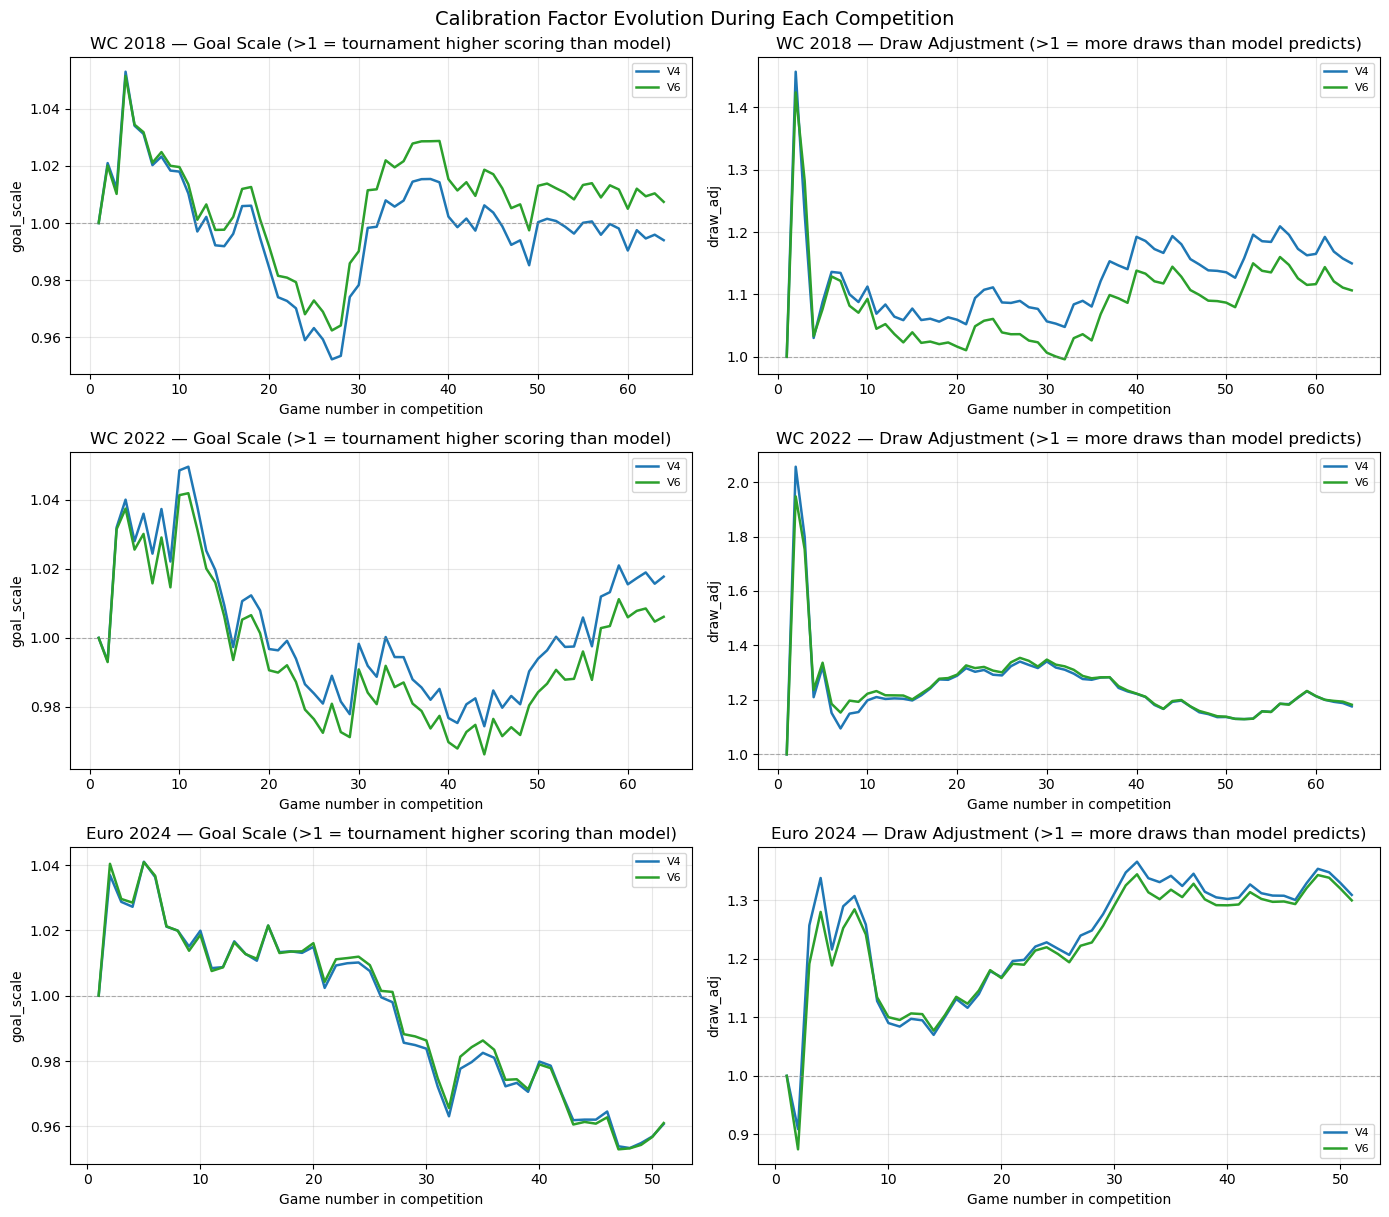

In [21]:
# ── Plot calibration factor evolution (goal_scale and draw_adj) ──────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=False)
colors = {'V4': '#1f77b4', 'V5': '#ff7f0e', 'V6': '#2ca02c'}

for row_idx, fold_name in enumerate(FOLDS):
    ax_goal = axes[row_idx, 0]
    ax_draw = axes[row_idx, 1]

    for strategy_name in STRATEGIES:
        snaps = CAL_SNAPS[(fold_name, strategy_name)]
        game_nums  = [s['game_num']   for s in snaps]
        goal_scale = [s['goal_scale'] for s in snaps]
        draw_adj   = [s['draw_adj']   for s in snaps]

        ax_goal.plot(game_nums, goal_scale, label=strategy_name,
                     color=colors[strategy_name], linewidth=1.8)
        ax_draw.plot(game_nums, draw_adj,   label=strategy_name,
                     color=colors[strategy_name], linewidth=1.8)

    ax_goal.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
    ax_draw.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

    ax_goal.set_title(f'{fold_name} — Goal Scale (>1 = tournament higher scoring than model)')
    ax_draw.set_title(f'{fold_name} — Draw Adjustment (>1 = more draws than model predicts)')
    ax_goal.set_xlabel('Game number in competition')
    ax_draw.set_xlabel('Game number in competition')
    ax_goal.set_ylabel('goal_scale')
    ax_draw.set_ylabel('draw_adj')
    ax_goal.legend(fontsize=8)
    ax_draw.legend(fontsize=8)
    ax_goal.grid(True, alpha=0.3)
    ax_draw.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Calibration Factor Evolution During Each Competition', y=1.01, fontsize=14)
plt.show()

### Calibration comparison: start vs end of competition

In [22]:
summary_cal_rows = []
for fold_name in FOLDS:
    for strategy_name in STRATEGIES:
        snaps = CAL_SNAPS[(fold_name, strategy_name)]
        prior_snap = snaps[0]   # before game 1 — pure prior
        final_snap = snaps[-1]  # after last prediction (but before last result is added)

        summary_cal_rows.append({
            'Fold':                fold_name,
            'Strategy':            strategy_name,
            'N games calibrated':  final_snap['n_games'],
            'Prior goals/game':    f"{prior_snap['prior_goals']:.2f}",
            'Final pred goals/g':  f"{final_snap['pred_goals']:.2f}" if final_snap['pred_goals'] is not None else '—',
            'Final actual goals/g':f"{final_snap['obs_goals']:.2f}"  if final_snap['obs_goals']  is not None else '—',
            'Final goal scale':    f"{final_snap['goal_scale']:.3f}",
            'Prior draw%':         f"{prior_snap['prior_draw_rate']:.1%}",
            'Final model draw%':   f"{final_snap['model_draw_rate']:.1%}",
            'Final actual draw%':  f"{final_snap['obs_draw_rate']:.1%}" if final_snap['obs_draw_rate'] is not None else '—',
            'Final posterior draw':f"{final_snap['post_draw_rate']:.1%}",
            'Final draw adj':      f"{final_snap['draw_adj']:.3f}",
        })

pd.DataFrame(summary_cal_rows)

,Fold,Strategy,N games calibrated,Prior goals/game,Final pred goals/g,Final actual goals/g,Final goal scale,Prior draw%,Final model draw%,Final actual draw%,Final posterior draw,Final draw adj
0,WC 2018,V4,63,2.57,2.61,2.59,0.994,23.8%,19.1%,20.6%,22.0%,1.150
1,WC 2018,V6,63,2.57,2.55,2.59,1.007,23.8%,19.9%,20.6%,22.0%,1.107
2,WC 2022,V4,63,2.57,2.56,2.63,1.018,24.2%,19.6%,22.2%,23.1%,1.176
3,WC 2022,V6,63,2.57,2.61,2.63,1.006,24.2%,19.5%,22.2%,23.1%,1.182
4,Euro 2024,V4,50,2.58,2.47,2.28,0.961,24.1%,22.3%,34.0%,29.2%,1.309
5,Euro 2024,V6,50,2.58,2.47,2.28,0.961,24.1%,22.4%,34.0%,29.2%,1.300


## 8 — Cumulative Accuracy During Each Competition

Shows how exact score % and result % evolve as more games are played,
comparing calibrated vs uncalibrated for each strategy.

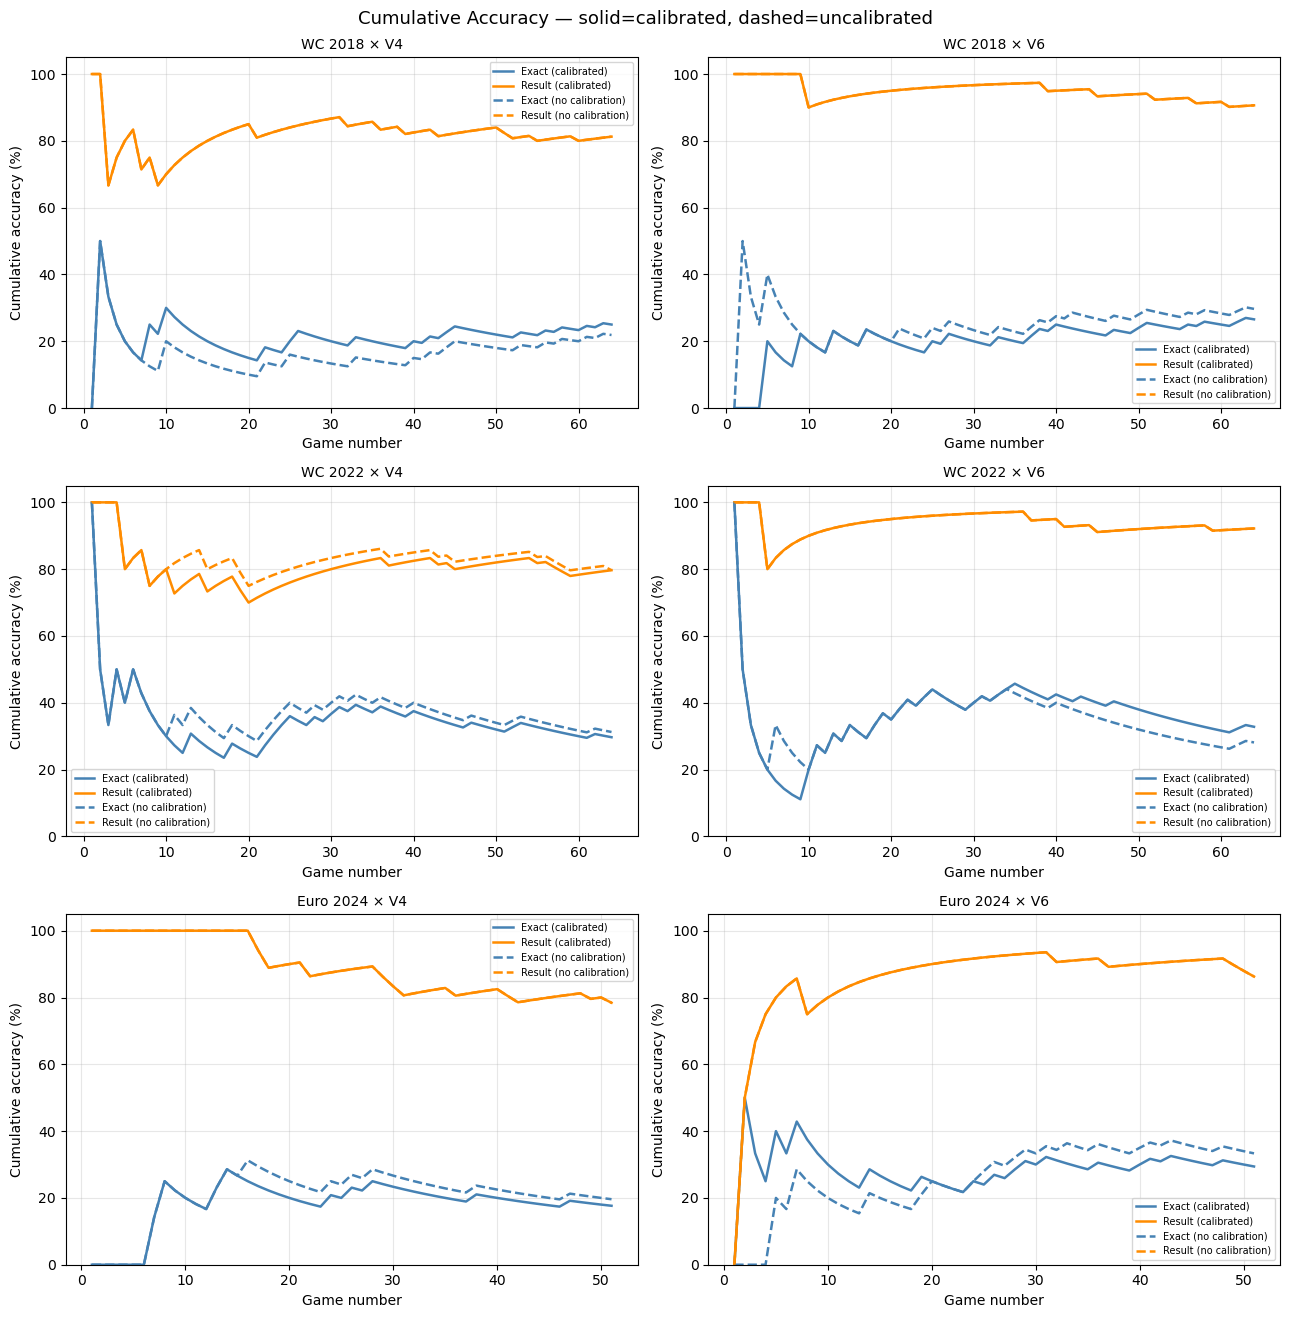

In [23]:
fig, axes = plt.subplots(3, 2, figsize=(13, 13))
line_styles = {'cal': '-', 'nocal': '--'}

for row_idx, fold_name in enumerate(FOLDS):
    for col_idx, strategy_name in enumerate(STRATEGIES):
        ax = axes[row_idx, col_idx]

        for mode, ls in line_styles.items():
            res = RESULTS[(fold_name, strategy_name, mode)]
            cum_exact  = res['exact_correct'].cumsum()  / (res.index + 1) * 100
            cum_result = res['result_correct'].cumsum() / (res.index + 1) * 100

            lbl = 'calibrated' if mode == 'cal' else 'no calibration'
            ax.plot(res['game_num'], cum_exact,  color='steelblue', ls=ls, lw=1.8, label=f'Exact ({lbl})')
            ax.plot(res['game_num'], cum_result, color='darkorange', ls=ls, lw=1.8, label=f'Result ({lbl})')

        ax.set_title(f'{fold_name} × {strategy_name}', fontsize=10)
        ax.set_xlabel('Game number')
        ax.set_ylabel('Cumulative accuracy (%)')
        ax.set_ylim(0, 105)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Cumulative Accuracy — solid=calibrated, dashed=uncalibrated', y=1.01, fontsize=13)
plt.show()

In [24]:
def _style_predictions(df: pd.DataFrame) -> '_PandasStyler':
    """Colour code rows: green=exact, yellow=correct result, red=wrong result."""
    def row_style(row):
        if row['exact_correct']:
            return ['background-color: #d4edda'] * len(row)
        if row['result_correct']:
            return ['background-color: #fff3cd'] * len(row)
        return ['background-color: #f8d7da'] * len(row)
    return df.style.apply(row_style, axis=1)


DISPLAY_COLS = [
    'game_num', 'date', 'team_a', 'team_b',
    'pred_a', 'pred_b', 'actual_a', 'actual_b',
    'exact_correct', 'result_correct',
    'la_raw', 'lb_raw', 'la_cal', 'lb_cal',
    'win_a', 'draw', 'win_b',
    'n_cal_games',
]


for fold_name in FOLDS:
    for strategy_name in STRATEGIES:
        res = RESULTS[(fold_name, strategy_name, 'cal')][DISPLAY_COLS].copy()
        m   = compute_metrics(res)

        print(f'\n{"─"*72}')
        print(f'  {fold_name} × {strategy_name} (calibrated)  |  '
              f'{m["exact_%"]:.1f}% exact  |  {m["result_%"]:.1f}% result  |  RPS {m["rps"]:.4f}')
        print(f'{"─"*72}')

        # Format probabilities as percentages for readability
        for c in ['win_a', 'draw', 'win_b']:
            res[c] = res[c].map('{:.1%}'.format)
        for c in ['la_raw', 'lb_raw', 'la_cal', 'lb_cal']:
            res[c] = res[c].map('{:.2f}'.format)

        res['Predicted'] = res['pred_a'].astype(str) + '–' + res['pred_b'].astype(str)
        res['Actual']    = res['actual_a'].astype(str) + '–' + res['actual_b'].astype(str)
        res['✓ Exact']   = res['exact_correct'].map({True: '✅', False: '❌'})
        res['✓ Result']  = res['result_correct'].map({True: '✅', False: '❌'})

        display_cols = [
            'game_num', 'date', 'team_a', 'team_b',
            'Predicted', 'Actual',
            '✓ Exact', '✓ Result',
            'la_raw', 'la_cal',
            'win_a', 'draw', 'win_b',
            'n_cal_games',
        ]
        display(_style_predictions(res[display_cols]))


────────────────────────────────────────────────────────────────────────
  WC 2018 × V4 (calibrated)  |  25.0% exact  |  81.2% result  |  RPS 0.0654
────────────────────────────────────────────────────────────────────────


KeyError: 'exact_correct'


────────────────────────────────────────────────────────────────────────
  WC 2018 × V6 (calibrated)  |  26.6% exact  |  90.6% result  |  RPS 0.0662
────────────────────────────────────────────────────────────────────────


KeyError: 'exact_correct'


────────────────────────────────────────────────────────────────────────
  WC 2022 × V4 (calibrated)  |  29.7% exact  |  79.7% result  |  RPS 0.0722
────────────────────────────────────────────────────────────────────────


...

KeyError: 'exact_correct'


────────────────────────────────────────────────────────────────────────
  Euro 2024 × V4 (calibrated)  |  17.6% exact  |  78.4% result  |  RPS 0.0901
────────────────────────────────────────────────────────────────────────


KeyError: 'exact_correct'


────────────────────────────────────────────────────────────────────────
  Euro 2024 × V6 (calibrated)  |  29.4% exact  |  86.3% result  |  RPS 0.0862
────────────────────────────────────────────────────────────────────────


KeyError: 'exact_correct'

In [25]:
improve_exact  = 0; neutral_exact  = 0; worse_exact  = 0
improve_result = 0; neutral_result = 0; worse_result = 0
improve_rps    = 0; neutral_rps    = 0; worse_rps    = 0

detail_rows = []
for fold_name in FOLDS:
    for strategy_name in STRATEGIES:
        m_n = compute_metrics(RESULTS[(fold_name, strategy_name, 'nocal')])
        m_c = compute_metrics(RESULTS[(fold_name, strategy_name, 'cal')])

        d_exact  = m_c['exact_%']  - m_n['exact_%']
        d_result = m_c['result_%'] - m_n['result_%']
        d_rps    = m_c['rps']      - m_n['rps']      # negative = better

        tol = 0.05  # percentage points tolerance for 'neutral'

        if d_exact > tol:   improve_exact  += 1
        elif d_exact < -tol: worse_exact   += 1
        else:                neutral_exact  += 1

        if d_result > tol:  improve_result += 1
        elif d_result < -tol: worse_result  += 1
        else:               neutral_result  += 1

        rps_tol = 0.001
        if d_rps < -rps_tol:  improve_rps  += 1   # lower = better
        elif d_rps > rps_tol:  worse_rps   += 1
        else:                  neutral_rps  += 1

total = len(FOLDS) * len(STRATEGIES)

verdict_df = pd.DataFrame([
    {'Metric':   'Exact score %',
     'Improved': f'{improve_exact}/{total}',
     'Neutral':  f'{neutral_exact}/{total}',
     'Worse':    f'{worse_exact}/{total}'},
    {'Metric':   'Result %',
     'Improved': f'{improve_result}/{total}',
     'Neutral':  f'{neutral_result}/{total}',
     'Worse':    f'{worse_result}/{total}'},
    {'Metric':   'RPS (lower=better)',
     'Improved': f'{improve_rps}/{total}',
     'Neutral':  f'{neutral_rps}/{total}',
     'Worse':    f'{worse_rps}/{total}'},
])

print(f'Does Bayesian calibration help?  (out of {total} fold × strategy combinations)')
display(verdict_df)

Does Bayesian calibration help?  (out of 6 fold × strategy combinations)


,Metric,Improved,Neutral,Worse
0,Exact score %,2/6,0/6,4/6
1,Result %,0/6,6/6,0/6
2,RPS (lower=better),1/6,3/6,2/6


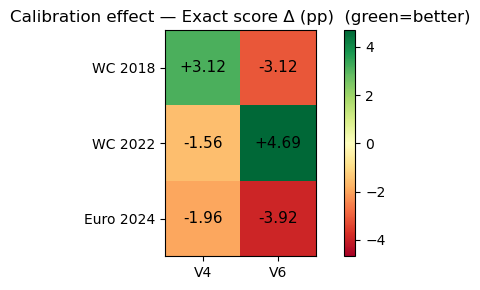

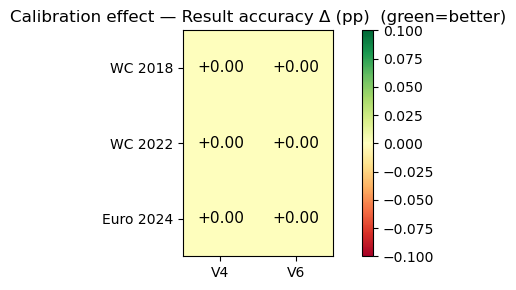

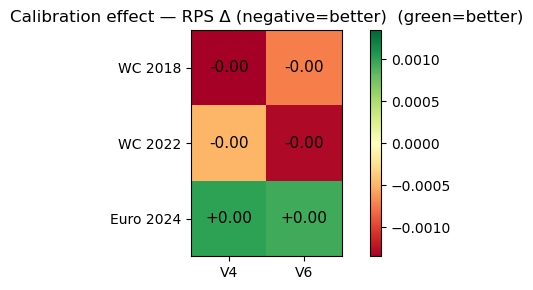

In [26]:
# ── Heat-map of calibration delta (calibrated − baseline, per fold × strategy) ──
import matplotlib.pyplot as plt
import numpy as np

fold_list     = list(FOLDS.keys())
strategy_list = list(STRATEGIES.keys())

for metric_key, metric_label, better_sign in [
    ('exact_%',  'Exact score Δ (pp)',   1),
    ('result_%', 'Result accuracy Δ (pp)', 1),
    ('rps',      'RPS Δ (negative=better)', -1),
]:
    matrix = np.zeros((len(fold_list), len(strategy_list)))
    for ri, fn in enumerate(fold_list):
        for ci, sn in enumerate(strategy_list):
            m_n = compute_metrics(RESULTS[(fn, sn, 'nocal')])
            m_c = compute_metrics(RESULTS[(fn, sn, 'cal')])
            delta = m_c[metric_key] - m_n[metric_key]
            matrix[ri, ci] = delta * better_sign  # positive = improvement

    fig, ax = plt.subplots(figsize=(6, 3))
    im = ax.imshow(matrix, cmap='RdYlGn', vmin=-max(abs(matrix.min()), abs(matrix.max())),
                                          vmax= max(abs(matrix.min()), abs(matrix.max())))
    ax.set_xticks(range(len(strategy_list))); ax.set_xticklabels(strategy_list)
    ax.set_yticks(range(len(fold_list)));     ax.set_yticklabels(fold_list)
    for ri in range(len(fold_list)):
        for ci in range(len(strategy_list)):
            ax.text(ci, ri, f'{matrix[ri,ci]:+.2f}', ha='center', va='center', fontsize=11)
    plt.colorbar(im, ax=ax)
    ax.set_title(f'Calibration effect — {metric_label}  (green=better)')
    plt.tight_layout()
    plt.show()